In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import matplotlib.ticker as mtick

In [5]:
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\dell\Downloads\churn analysis\customer_data.csv")

In [7]:
df

,customer_id,plan_type,contract_type,monthly_charge,tenure_months,signup_date,payment_method,autopay_enabled,usage_score,logins_per_month,features_used,support_tickets_6m,complaint_unresolved,total_revenue,churned,churn_date,last_active_date
0,CUST100500,Standard,Month-to-month,21.31,20,2020-01-03,Credit card,1,78.8,8,8,2,1,426.20,0,NaN,2021-09-02
1,CUST101041,Standard,Month-to-month,19.80,33,2020-01-03,Manual/Invoice,1,46.1,20,4,0,0,653.40,0,NaN,2022-10-03
2,CUST100305,Premium,Month-to-month,40.58,18,2020-01-04,Bank transfer,1,49.8,17,6,3,0,730.44,0,NaN,2021-07-04
3,CUST101045,Standard,Month-to-month,20.46,57,2020-01-07,Credit card,0,42.4,10,3,1,0,1166.22,0,NaN,2024-10-07
4,CUST101341,Standard,Month-to-month,20.96,9,2020-01-07,Bank transfer,1,54.2,17,6,2,1,188.64,0,NaN,2020-10-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,CUST100603,Basic,Month-to-month,8.39,9,2025-06-18,PayPal,1,88.5,27,7,1,1,75.51,0,NaN,2026-03-18
1496,CUST100239,Basic,Month-to-month,9.33,2,2025-06-18,Credit card,1,65.6,19,6,4,1,18.66,1,2025-08-17,2025-08-17
1497,CUST100050,Premium,Month-to-month,38.75,8,2025-06-20,Credit card,1,43.6,13,3,0,0,310.00,0,NaN,2026-02-18
1498,CUST100878,Basic,Month-to-month,9.96,3,2025-06-21,Credit card,1,66.2,11,7,4,1,29.88,1,2025-09-20,2025-09-20


In [8]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

bins = [-1, 6, 12, 24, 999]
labels = ["0-6mo", "6-12mo", "12-24mo", "24mo+"]
df["tenure_bucket"] = pd.cut(df["tenure_months"], bins=bins, labels=labels)


In [9]:

df["tenure_bucket"]

0       12-24mo
1         24mo+
2       12-24mo
3         24mo+
4        6-12mo
         ...   
1495     6-12mo
1496      0-6mo
1497     6-12mo
1498      0-6mo
1499      24mo+
Name: tenure_bucket, Length: 1500, dtype: category
Categories (4, str): ['0-6mo' < '6-12mo' < '12-24mo' < '24mo+']

In [10]:
df.head()

,customer_id,plan_type,contract_type,monthly_charge,tenure_months,signup_date,payment_method,autopay_enabled,usage_score,logins_per_month,features_used,support_tickets_6m,complaint_unresolved,total_revenue,churned,churn_date,last_active_date,tenure_bucket
0,CUST100500,Standard,Month-to-month,21.31,20,2020-01-03,Credit card,1,78.8,8,8,2,1,426.20,0,NaN,2021-09-02,12-24mo
1,CUST101041,Standard,Month-to-month,19.80,33,2020-01-03,Manual/Invoice,1,46.1,20,4,0,0,653.40,0,NaN,2022-10-03,24mo+
2,CUST100305,Premium,Month-to-month,40.58,18,2020-01-04,Bank transfer,1,49.8,17,6,3,0,730.44,0,NaN,2021-07-04,12-24mo
3,CUST101045,Standard,Month-to-month,20.46,57,2020-01-07,Credit card,0,42.4,10,3,1,0,1166.22,0,NaN,2024-10-07,24mo+
4,CUST101341,Standard,Month-to-month,20.96,9,2020-01-07,Bank transfer,1,54.2,17,6,2,1,188.64,0,NaN,2020-10-06,6-12mo


# Churn rate by plan/contract/tenure 

In [11]:
rates = df.groupby("plan_type")["churned"].mean() * 100

In [12]:
rates

plan_type
Basic       20.417288
Premium     19.614148
Standard    16.602317
Name: churned, dtype: float64

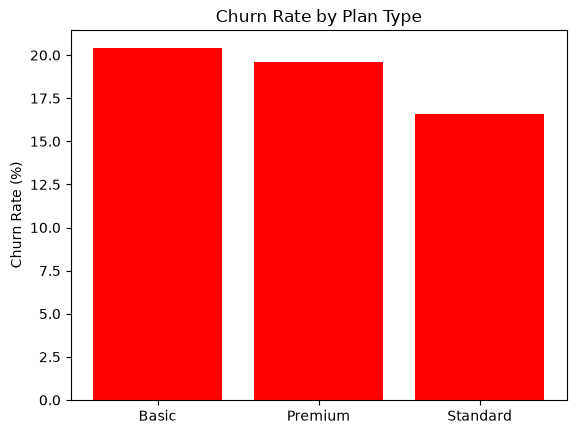

In [13]:
plt.bar(rates.index, rates.values, color="red")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Plan Type")
plt.xticks(rotation=0)
plt.show()

In [14]:
revenue = df.groupby("churned")["total_revenue"].agg(["sum", "mean"])
revenue.index = ["Retained", "Churned"]


# Revenue comparison (churned vs retained)

In [15]:
revenue

,sum,mean
Retained,511265.37,420.448495
Churned,91109.60,320.808451


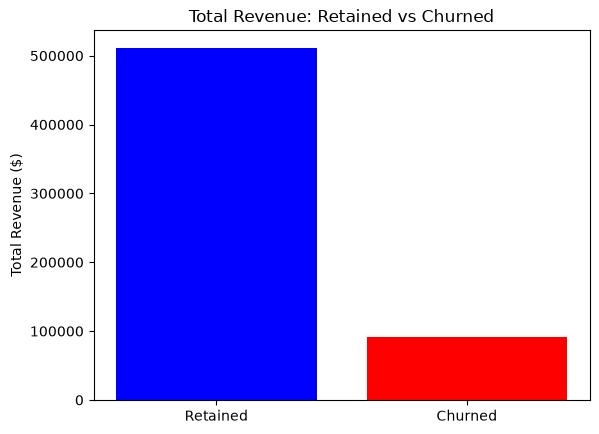

In [16]:
plt.bar(revenue.index, revenue["sum"], color=["blue", "red"])
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue: Retained vs Churned")
plt.xticks(rotation=0)
plt.show()

# Usage & complaints chart


In [17]:
usage = df.groupby("churned")[["usage_score", "logins_per_month", "features_used"]].mean()
usage.index = ["Retained", "Churned"]

In [18]:
usage

,usage_score,logins_per_month,features_used
Retained,55.961513,17.037007,5.532072
Churned,47.295775,14.158451,4.767606


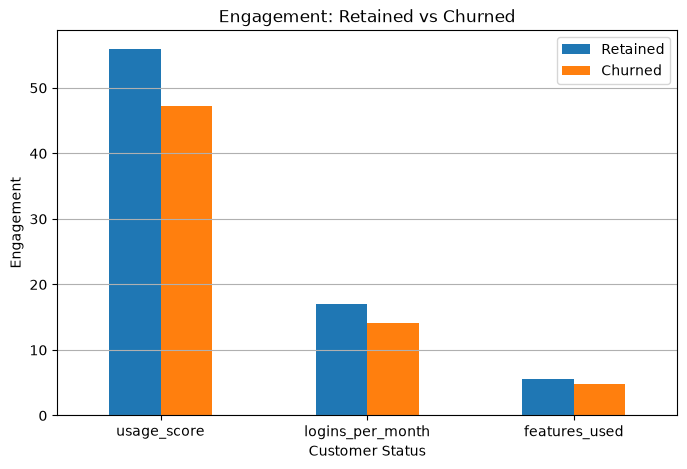

In [19]:
usage.T.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Customer Status")
plt.ylabel("Engagement")
plt.title("Engagement: Retained vs Churned")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

# Complaints impact

In [20]:
comp_rate = df.groupby("complaint_unresolved")["churned"].mean() * 100
comp_rate.index = ["No Unresolved", "Has Unresolved"]

In [21]:
comp_rate

No Unresolved     15.567766
Has Unresolved    27.941176
Name: churned, dtype: float64

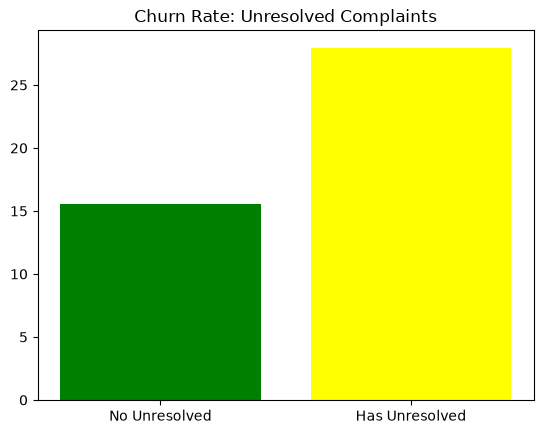

In [22]:
plt.bar(comp_rate.index, comp_rate.values, color=["green", "yellow"])
plt.title("Churn Rate: Unresolved Complaints")
plt.show()

## Cohort retention heatmap

In [23]:
df["signup_month"] = df["signup_date"].dt.to_period("M")
cohort = df.pivot_table(
    index=df["signup_month"].astype(str),
    columns=pd.cut(df["tenure_months"], bins=[-1,6,12,18,24,36,999],
                    labels=["0-6","6-12","12-18","18-24","24-36","36+"]),
    values="churned",
    aggfunc=lambda x: 100*(1-x.mean()),
    observed=True
)



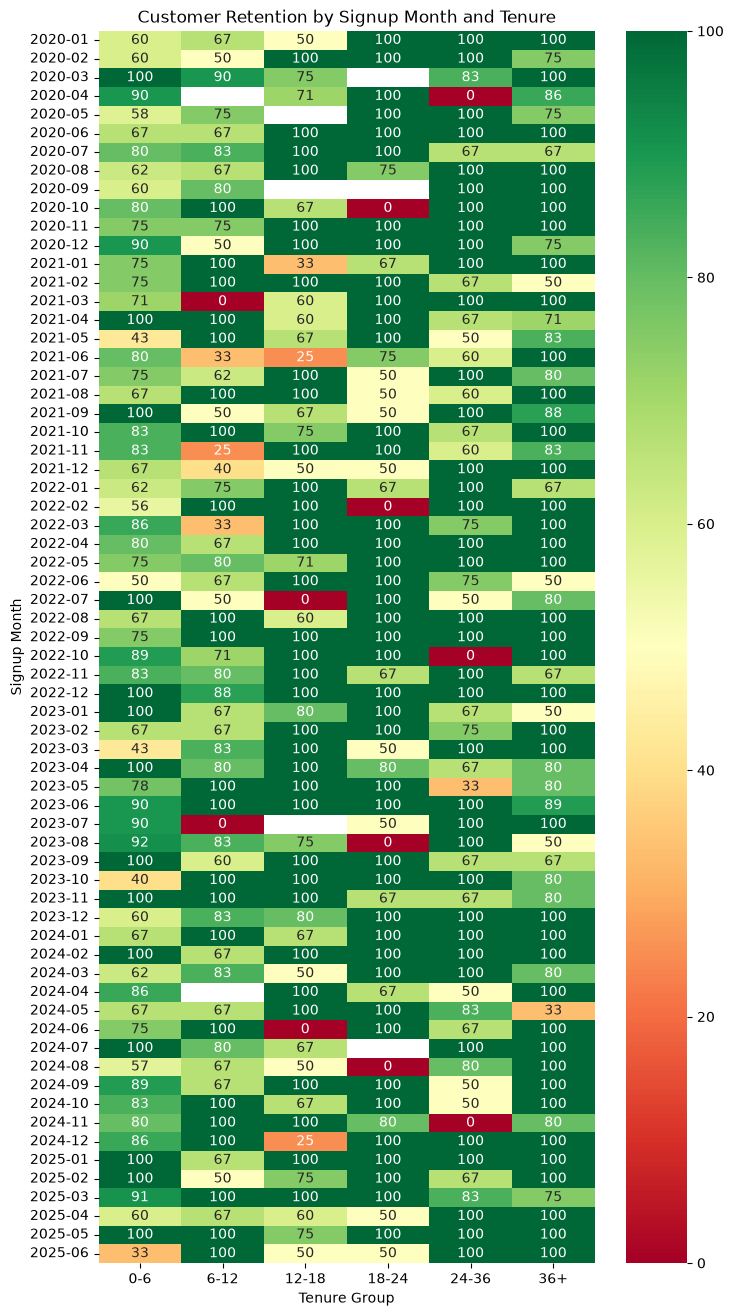

In [24]:
plt.figure(figsize=(8,16))
sns.heatmap(
    cohort,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100
)

plt.title("Customer Retention by Signup Month and Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Signup Month")
plt.show()

# Correlation matrix

In [25]:
num_cols = ["tenure_months","usage_score","logins_per_month","support_tickets_6m",
            "complaint_unresolved","total_revenue","churned"]
corr = df[num_cols].corr()


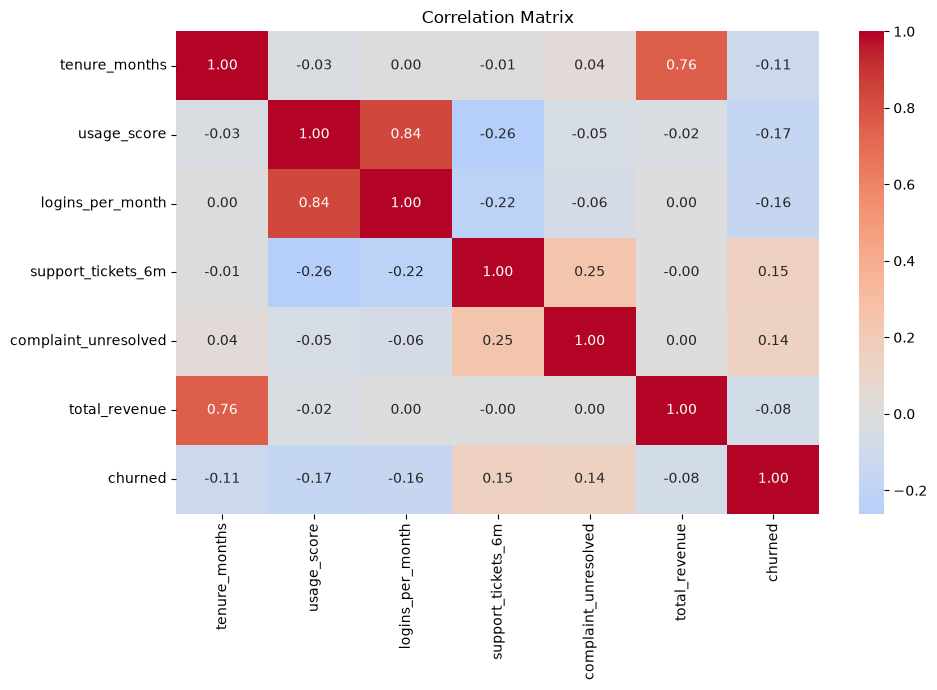

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [27]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

FEATURES_NUM = ["monthly_charge", "tenure_months", "usage_score", "logins_per_month",
                 "features_used", "support_tickets_6m", "complaint_unresolved",
                 "autopay_enabled"]
FEATURES_CAT = ["plan_type", "contract_type", "payment_method"]

X = df[FEATURES_NUM + FEATURES_CAT]
y = df["churned"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [30]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

# Preprocess — scale numbers, encode categories

In [31]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

# Logistic Regression model

In [32]:
logreg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
logreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['monthly_charge','tenure_months','usage_score',...,'plan_type', 'contract_type','payment_method']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [33]:
logreg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['monthly_charge','tenure_months','usage_score',...,'plan_type', 'contract_type','payment_method']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [34]:
from sklearn.metrics import roc_auc_score

logreg_proba = logreg.predict_proba(X_test)[:, 1]
logreg_auc = roc_auc_score(y_test, logreg_proba)


In [35]:
logreg_auc

0.7953576723498887

In [36]:
logreg_proba

array([0.28940773, 0.80168467, 0.06990235, 0.79920921, 0.24358739,
       0.75524284, 0.49899961, 0.79421657, 0.23610128, 0.24888991,
       0.35003228, 0.58513611, 0.22307799, 0.5996803 , 0.16697565,
       0.89810743, 0.42923321, 0.44660088, 0.35499707, 0.44016671,
       0.1934879 , 0.71975538, 0.30738563, 0.19071466, 0.33731433,
       0.25234842, 0.49057352, 0.07123762, 0.57843876, 0.51665681,
       0.32527102, 0.31733846, 0.73267545, 0.60047578, 0.18854105,
       0.61803971, 0.64056672, 0.35199625, 0.17388393, 0.23672962,
       0.63513873, 0.33587086, 0.30103742, 0.10206165, 0.41317114,
       0.39006992, 0.30511864, 0.05766632, 0.61927197, 0.69116497,
       0.66732559, 0.44557637, 0.47176798, 0.32104672, 0.37335955,
       0.35172542, 0.38210059, 0.17301927, 0.06119957, 0.50317084,
       0.51482709, 0.5848426 , 0.48580448, 0.09421903, 0.17534938,
       0.49543982, 0.60643258, 0.26973741, 0.83073216, 0.26112544,
       0.53619218, 0.49677669, 0.5956054 , 0.10111917, 0.57587

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=6,
                                     class_weight="balanced", random_state=42))
])
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
rf_auc

0.7580151964418088

In [38]:
feature_names = (FEATURES_NUM +
    list(rf.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT)))
importances = rf.named_steps["clf"].feature_importances_

import pandas as pd
imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

In [39]:
imp_series.head(10)

contract_type_Month-to-month    0.155464
usage_score                     0.148141
tenure_months                   0.129378
logins_per_month                0.122058
monthly_charge                  0.099579
contract_type_One year          0.069223
features_used                   0.051983
support_tickets_6m              0.047464
contract_type_Two year          0.040505
complaint_unresolved            0.030395
dtype: float64

# active customer and build the at-risk list

In [40]:
active = df[df["churned"] == 0].copy()
active["churn_probability"] = rf.predict_proba(active[FEATURES_NUM + FEATURES_CAT])[:, 1]
active_sorted = active.sort_values("churn_probability", ascending=False)

top50 = active_sorted.head(50)[
    ["customer_id", "plan_type", "contract_type", "tenure_months",
     "usage_score", "support_tickets_6m", "total_revenue", "churn_probability"]
].copy()
top50["churn_probability"] = (top50["churn_probability"] * 100).round(1)


In [41]:
top50.head(10)


,customer_id,plan_type,contract_type,tenure_months,usage_score,support_tickets_6m,total_revenue,churn_probability
234,CUST100341,Standard,Month-to-month,12,1.5,5,233.28,81.3
1142,CUST100505,Basic,Month-to-month,9,31.7,2,89.73,79.8
138,CUST100830,Basic,Month-to-month,13,27.7,4,140.27,78.0
348,CUST100710,Standard,Month-to-month,23,12.8,5,434.24,77.5
484,CUST101478,Standard,Month-to-month,11,41.0,3,208.56,77.2
472,CUST100248,Premium,Month-to-month,7,9.9,4,277.69,76.9
782,CUST101321,Basic,Month-to-month,7,23.3,3,81.97,76.3
822,CUST100406,Basic,Month-to-month,7,38.8,1,70.42,76.0
780,CUST100934,Basic,Month-to-month,7,47.2,3,77.21,75.8
210,CUST100004,Basic,Month-to-month,10,31.8,1,110.10,75.6


In [43]:
top50.to_csv("at_risk_customers.csv", index=False)

In [44]:
active = df[df["churned"] == 0].copy()
active["churn_probability"] = rf.predict_proba(active[FEATURES_NUM + FEATURES_CAT])[:, 1]
active["churn_probability"] = (active["churn_probability"] * 100).round(1)
active_sorted = active.sort_values("churn_probability", ascending=False)

active_sorted.to_csv("all_active_customers_scored.csv", index=False)

In [45]:
import os
print(os.getcwd())

C:\Users\dell


In [46]:
check = pd.read_csv("all_active_customers_scored.csv")
print(check.shape)
check.head()

(1216, 20)


,customer_id,plan_type,contract_type,monthly_charge,tenure_months,signup_date,payment_method,autopay_enabled,usage_score,logins_per_month,features_used,support_tickets_6m,complaint_unresolved,total_revenue,churned,churn_date,last_active_date,tenure_bucket,signup_month,churn_probability
0,CUST100341,Standard,Month-to-month,19.44,12,2020-11-19,PayPal,1,1.5,0,0,5,0,233.28,0,NaN,2021-11-19,6-12mo,2020-11,81.3
1,CUST100505,Basic,Month-to-month,9.97,9,2024-02-02,Credit card,0,31.7,8,2,2,1,89.73,0,NaN,2024-11-01,6-12mo,2024-02,79.8
2,CUST100830,Basic,Month-to-month,10.79,13,2020-07-05,Credit card,0,27.7,5,4,4,0,140.27,0,NaN,2021-08-04,12-24mo,2020-07,78.0
3,CUST100710,Standard,Month-to-month,18.88,23,2021-04-21,PayPal,1,12.8,3,2,5,0,434.24,0,NaN,2023-03-22,12-24mo,2021-04,77.5
4,CUST101478,Standard,Month-to-month,18.96,11,2021-10-20,Bank transfer,0,41.0,8,3,3,0,208.56,0,NaN,2022-09-19,6-12mo,2021-10,77.2
